### Préparation : Importation des données et des librairies

In [1]:
### Importation des librairies ###


import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from fonction import *
import seaborn as sns
import gc
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import xgboost as xgb
import time

In [2]:
### Importation de la base ###


# Importation
gdf = gpd.read_file('data/processed/jointure_meteo_swimonthly_full.gpkg')

# Affichage
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,HTEURNEIGE,HTEURNEIGE6,HTEURNEIGEX,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,geometry
0,2,641374,7106309,1960-01-01,0.863,4.9,51.5,4.829032,6.822581,4.584839,...,0.001710,0.001839,0.024,0.096774,4.0,0.287032,0.002484,-7.2,11.6,POINT (588001.454 2673000.704)
1,7119,635809,6442801,1960-01-01,1.081,20.2,96.4,1.990323,2.061290,3.926677,...,0.030935,0.031323,0.174,0.177419,38.0,0.298742,0.012194,-13.1,11.7,POINT (587999.304 2008998.388)
2,7118,627817,6442868,1960-01-01,1.100,22.7,119.8,2.783871,1.996774,4.188290,...,0.032935,0.033581,0.180,0.203226,50.2,0.264548,0.012129,-12.8,12.2,POINT (579999.298 2008998.399)
3,7117,619825,6442935,1960-01-01,1.095,21.8,115.4,3.277419,2.083871,4.315355,...,0.030839,0.031226,0.170,0.180645,45.7,0.284097,0.010065,-12.2,13.0,POINT (571999.291 2008998.458)
4,7116,611833,6443002,1960-01-01,1.086,23.8,108.4,3.490323,2.174194,4.422677,...,0.032871,0.033323,0.179,0.183871,41.7,0.293774,0.008742,-11.5,13.3,POINT (563999.284 2008998.565)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,3831,805955,6713138,2024-12-01,0.927,0.9,68.4,4.016129,2.809677,4.880258,...,0.000000,0.000000,0.000,0.000000,0.9,0.344613,0.000097,-3.9,12.8,POINT (756000.273 2280998.1)
7005176,3832,813948,6713070,2024-12-01,0.908,1.5,71.1,2.861290,3.348387,4.495484,...,0.000000,0.000000,0.001,0.000000,1.8,0.324968,0.000613,-5.0,11.4,POINT (763999.644 2280998.186)
7005177,3833,821942,6713002,2024-12-01,0.923,3.2,71.2,2.835484,3.409677,4.498032,...,0.000000,0.000000,0.001,0.000000,3.9,0.321000,0.000516,-4.8,11.5,POINT (772000.016 2280998.33)
7005178,3827,773980,6713410,2024-12-01,0.973,0.0,64.9,4.154839,2.825806,4.791226,...,0.000000,0.000000,0.000,0.000000,0.0,0.375032,0.000774,-2.5,13.3,POINT (723999.802 2280998.23)


In [3]:
### Affichage de la liste des variables ###


list(gdf.columns)

['NUMERO',
 'LAMBX',
 'LAMBY',
 'DATE',
 'SWI_UNIF_MENS',
 'PRENEI',
 'PRELIQ',
 'T',
 'FF',
 'Q',
 'DLI',
 'SSI',
 'HU',
 'EVAP',
 'ETP',
 'PE',
 'SWI',
 'SSWI_10J',
 'DRAINC',
 'RUNC',
 'RESR_NEIGE',
 'RESR_NEIGE6',
 'HTEURNEIGE',
 'HTEURNEIGE6',
 'HTEURNEIGEX',
 'SNOW_FRAC',
 'ECOULEMENT',
 'WG_RACINE',
 'WGI_RACINE',
 'TINF_H',
 'TSUP_H',
 'geometry']

In [4]:
### Optimisation de la mémoire : conversion des float64 en float32 ###


# Sélection des colonnes de type float64
cols_float = gdf.select_dtypes(include=['float64']).columns

# Conversion en float32
gdf[cols_float] = gdf[cols_float].astype('float32')

gc.collect()

0

In [5]:
### Isolement de la variable de SWI uniforme mensuel (y) et des variables météorologiques ###


# Variable de SWI uniforme mensuel
y = gdf["SWI_UNIF_MENS"]

# Variables météorologiques
meteo_vars = [
    "T", "Q", "FF",
    "PRENEI", "PRELIQ",
    "SSI", "DLI",
    "EVAP", "ETP",
    "PE", "DRAINC", "RUNC",
    "RESR_NEIGE", "RESR_NEIGE6",
    "HTEURNEIGE", "HTEURNEIGE6", "HTEURNEIGEX",
    "SNOW_FRAC", "ECOULEMENT",
    "WG_RACINE", "WGI_RACINE",
    "TINF_H", "TSUP_H"
]

### Premier enrichissement de la base

In [6]:
### Ajout du cosinus et du sinus à partir du mois ###


# Copie du dataframe
gdf = gdf.copy()

# Extraction du mois
gdf["month"] = gdf["DATE"].dt.month

# Calcul du sinus et du cosinus à partir du mois pour capturer la saisonnalité
gdf["sin_month"] = np.sin(2 * np.pi * gdf["month"] / 12)
gdf["cos_month"] = np.cos(2 * np.pi * gdf["month"] / 12)

# Coordonnées x et y des points
gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y

# Modèles sans temporalité

### Bases d'entraînement et de test sans variables de lag, diff et cumul

In [7]:
### Dataframes des variables explicatives X et de la variable cible Y ###


# Liste des variables explicatives
X_cols = (
    meteo_vars +
    ["sin_month", "cos_month", "x", "y"]
)

# Dataframes X et y
# X = gdf[X_cols]
# y = gdf["SWI_UNIF_MENS"]

In [8]:
### Séparation des données en bases d'entraînement et de test ###


# Bases d'entraînement et de test
train = gdf[gdf["DATE"] < "2018-01-01"]
test  = gdf[gdf["DATE"] >= "2018-01-01"]

# X et y d'entraînement
X_train = train[X_cols]
y_train = train["SWI_UNIF_MENS"]

# X et y de test
X_test = test[X_cols]
y_test = test["SWI_UNIF_MENS"]

# Création de masques pour le découpage de la base d'entraînement
masque_train_train = gdf["DATE"] < "2017-01-01"
masque_val = (gdf["DATE"] >= "2017-01-01") & (gdf["DATE"] < "2018-01-01")

# Dates uniques de la base de test
dates_test = np.sort(gdf[gdf["DATE"] >= "2018-01-01"]['DATE'].unique())

### Premier modèle : Régression Ridge sans CV

In [9]:
model_ridge = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ]
)

In [10]:
model_ridge.fit(X_train, y_train)

y_pred = model_ridge.predict(X_test)

# Print the complete summary of the model's performance
print("Model coefficients:", model_ridge.named_steps['reg'].coef_)
print("Model intercept:", model_ridge.named_steps['reg'].intercept_)
print("R² (train):", model_ridge.score(X_train, y_train))
print("R² (test):", model_ridge.score(X_test, y_test))
print("RMSE (train):", np.sqrt(metrics.mean_squared_error(y_train, model_ridge.predict(X_train))))
print("RMSE (test):", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Model coefficients: [-1.31258472e-01  6.39092998e-02 -9.63786522e-03  1.35249507e-01
  2.48783723e-01 -8.96048112e-02 -2.56905634e-02 -2.25467230e-02
 -3.44168150e-02 -3.51228459e-01  1.33227664e-01  5.18742395e-02
  2.51380683e+00 -2.46599267e+00 -3.05247392e+00  2.96502490e+00
  2.86053309e-02  5.08823092e-03 -7.39635929e-02  5.65694102e-02
  2.31541403e-02  2.39290140e-02 -2.51108312e-02  1.03463923e-01
 -2.74996458e-02  1.51372278e-03  6.22562745e-04]
Model intercept: 0.6173501262799079
R² (train): 0.876723705910494
R² (test): 0.862376582233723
RMSE (train): 0.1142338993607485
RMSE (test): 0.12658750417485085


In [11]:
y_test

6250776    1.083
6250777    1.083
6250778    1.090
6250779    1.080
6250780    1.174
           ...  
7005175    0.927
7005176    0.908
7005177    0.923
7005178    0.973
7005179    0.177
Name: SWI_UNIF_MENS, Length: 754404, dtype: float32

In [12]:
y_pred

array([0.97850538, 1.02763067, 1.00444066, ..., 0.7429092 , 0.80558519,
       0.44517435], shape=(754404,))

### Deuxième modèle : Random Forest sans CV

In [13]:
# ==========================================
# CONFIGURATION DU MODÈLE
# ==========================================
# On limite la profondeur et l'échantillonnage pour éviter le crash RAM
rf_model = RandomForestRegressor(
    n_estimators=100,        # 100 arbres est un standard pour commencer (XGBoost en avait 1000+)
    max_depth=8,            # IMPORTANT : Limite la profondeur (sinon l'arbre grandit à l'infini)
    min_samples_leaf=50,     # Equivalent du min_child_weight de XGBoost (réduit le bruit)
    max_samples=0.5,         # <--- L'ASTUCE : Chaque arbre ne voit que 50% des lignes
    n_jobs=-1,               # Utilise tous les processeurs (parallélisation indispensable)
    random_state=42,
    verbose=2                # Affiche la progression
)

# ==========================================
# ENTRAÎNEMENT
# ==========================================
print("Démarrage de l'entraînement Random Forest...")
start_time = time.time()

# Note : Random Forest n'a pas besoin d'eval_set ni d'early_stopping
# Il est difficile de faire sur-apprendre une Random Forest en ajoutant des arbres.
rf_model.fit(X_train, y_train)

duration = time.time() - start_time
print(f"Entraînement terminé en {duration/60:.1f} minutes.")

# ==========================================
# ÉVALUATION
# ==========================================
print("Calcul des prédictions...")
preds_rf = rf_model.predict(X_test)
rmse_rf = metrics.root_mean_squared_error(y_test, preds_rf)

print("------------------------------------------------")
print(f"RMSE Random Forest : {rmse_rf:.4f}")
print("------------------------------------------------")

Démarrage de l'entraînement Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


building tree 1 of 100building tree 2 of 100
building tree 3 of 100

building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.3min


building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  8.2min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s


Entraînement terminé en 8.3 minutes.
Calcul des prédictions...
------------------------------------------------
RMSE Random Forest : 0.1355
------------------------------------------------


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.2s finished


### Troisième modèle : XGBoost sans CV

C:\Users\thoma\AppData\Local\Temp\ipykernel_25820\1162955323.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train_train = X_train[masque_train_train]
C:\Users\thoma\AppData\Local\Temp\ipykernel_25820\1162955323.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_val = X_train[masque_val]


Lancement de l'entraînement...
[0]	validation_0-rmse:0.31036	validation_1-rmse:0.32025
[50]	validation_0-rmse:0.07450	validation_1-rmse:0.14852
[100]	validation_0-rmse:0.06215	validation_1-rmse:0.12359
[150]	validation_0-rmse:0.05909	validation_1-rmse:0.11869
[200]	validation_0-rmse:0.05719	validation_1-rmse:0.11493
[250]	validation_0-rmse:0.05562	validation_1-rmse:0.11174
[300]	validation_0-rmse:0.05460	validation_1-rmse:0.10922
[350]	validation_0-rmse:0.05375	validation_1-rmse:0.10735
[400]	validation_0-rmse:0.05308	validation_1-rmse:0.10485
[450]	validation_0-rmse:0.05248	validation_1-rmse:0.10290
[500]	validation_0-rmse:0.05197	validation_1-rmse:0.10151
[550]	validation_0-rmse:0.05154	validation_1-rmse:0.10011
[600]	validation_0-rmse:0.05108	validation_1-rmse:0.09845
[650]	validation_0-rmse:0.05070	validation_1-rmse:0.09709
[700]	validation_0-rmse:0.05028	validation_1-rmse:0.09581
[750]	validation_0-rmse:0.05000	validation_1-rmse:0.09498
[800]	validation_0-rmse:0.04967	validation_1

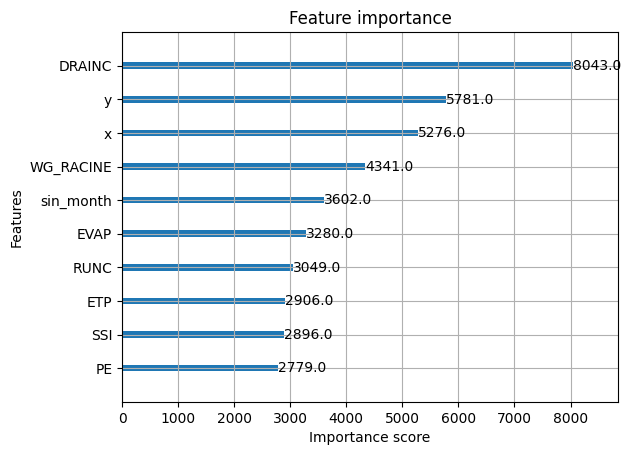

In [14]:
### Modèle de XGBoost sans CV ###


# Découpage de X_train et y_train en sous-ensembles d'apprentissage et de validation
X_train_train = X_train[masque_train_train]
y_train_train = y_train[masque_train_train]
X_val = X_train[masque_val]
y_val = y_train[masque_val]

# ==========================================
# 3. ENTRAÎNEMENT DU MODÈLE
# ==========================================
model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=5,
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
    subsample=0.7,
    min_child_weight=50,
)

print("Lancement de l'entraînement...")

# On garde eval_set ici, car le modèle a besoin des données de test
# pour savoir quand s'arrêter, mais on enlève le paramètre early_stopping_rounds.
model.fit(
    X_train, y_train,
    eval_set=[(X_train_train, y_train_train), (X_val, y_val)],
    verbose=50 
)

# ==========================================
# 4. ÉVALUATION
# ==========================================
preds_val = model.predict(X_val)
rmse_val = metrics.root_mean_squared_error(y_val, preds_val)

print("------------------------------------------------")
print(f"RMSE Finale : {rmse_val:.4f}")
print("------------------------------------------------")

# Optionnel : Voir quelles variables sont importantes
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=10)
plt.show()

In [15]:
### Prédiction avec le XGBoost ###


# Prédiction sur la base de test
preds_test = model.predict(X_test)
rmse_test = metrics.root_mean_squared_error(y_test, preds_test)

print("------------------------------------------------")
print(f"RMSE sur la base de test : {rmse_test:.4f}")
print("------------------------------------------------")

------------------------------------------------
RMSE sur la base de test : 0.0843
------------------------------------------------


In [16]:
### Suppression des bases d'entraînement et de test pour libérer de la mémoire ###

del train, test, X_train, X_train_train, X_val, X_test, y_train, y_train_train, y_val, y_test
gc.collect()

4639

# Modèles avec temporalité

### Préparation de variables de lag, diff et cumul

In [17]:
### Ajout d'une colonne de SWI des deux périodes précédentes (lag 1 et lag 2) ###


# Tri de la base par point de la grille puis par date
gdf = gdf.sort_values(by=["NUMERO", "DATE"])

# Ajout de la colonne SWI_UNIF_MENS_LAG1
gdf["SWI_UNIF_MENS_LAG1"] = gdf.groupby("NUMERO")["SWI_UNIF_MENS"].shift(1)

# Ajout de la colonne SWI_UNIF_MENS_LAG2
gdf["SWI_UNIF_MENS_LAG2"] = gdf.groupby("NUMERO")["SWI_UNIF_MENS"].shift(2)

# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,TINF_H,TSUP_H,geometry,month,sin_month,cos_month,x,y,SWI_UNIF_MENS_LAG1,SWI_UNIF_MENS_LAG2
0,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,-7.2,11.600000,POINT (588001.454 2673000.704),1,5.000000e-01,8.660254e-01,5.880015e+05,2.673001e+06,NaN,NaN
15717,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,-0.7,17.900000,POINT (588001.454 2673000.704),2,8.660254e-01,5.000000e-01,5.880015e+05,2.673001e+06,0.863,NaN
23945,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,-0.8,14.600000,POINT (588001.454 2673000.704),3,1.000000e+00,6.123234e-17,5.880015e+05,2.673001e+06,0.876,0.863
33679,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,3.5,20.400000,POINT (588001.454 2673000.704),4,8.660254e-01,-5.000000e-01,5.880015e+05,2.673001e+06,0.856,0.876
41906,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,1.7,23.500000,POINT (588001.454 2673000.704),5,5.000000e-01,-8.660254e-01,5.880015e+05,2.673001e+06,0.757,0.856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6964764,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,17.1,37.700001,POINT (1171999.296 1617001.255),8,-8.660254e-01,-5.000000e-01,1.171999e+06,1.617001e+06,-0.019,0.057
6971499,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,8.2,32.900002,POINT (1171999.296 1617001.255),9,-1.000000e+00,-1.836970e-16,1.171999e+06,1.617001e+06,-0.019,-0.019
6981220,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,7.0,30.400000,POINT (1171999.296 1617001.255),10,-8.660254e-01,5.000000e-01,1.171999e+06,1.617001e+06,0.007,-0.019
6988708,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,0.1,24.100000,POINT (1171999.296 1617001.255),11,-5.000000e-01,8.660254e-01,1.171999e+06,1.617001e+06,0.170,0.007


In [18]:

### Ajout de colonnes de variables climatiques des périodes précédentes (lag) ###

# WGRACINE et WGI_RACINE lag 1
gdf["WG_RACINE_LAG1"] = gdf.groupby("NUMERO")["WG_RACINE"].shift(1)
gdf["WGI_RACINE_LAG1"] = gdf.groupby("NUMERO")["WGI_RACINE"].shift(1)

# DRAINC, RUNC et ECOULEMENT lag 1
gdf["DRAINC_LAG1"] = gdf.groupby("NUMERO")["DRAINC"].shift(1)
gdf["RUNC_LAG1"] = gdf.groupby("NUMERO")["RUNC"].shift(1)
gdf["ECOULEMENT_LAG1"] = gdf.groupby("NUMERO")["ECOULEMENT"].shift(1)

# RESR_NEIGE, HTEURNEIGE et SNOW_FRAC lag 1
gdf["RESR_NEIGE_LAG1"] = gdf.groupby("NUMERO")["RESR_NEIGE"].shift(1)
gdf["HTEURNEIGE_LAG1"] = gdf.groupby("NUMERO")["HTEURNEIGE"].shift(1)
gdf["SNOW_FRAC_LAG1"] = gdf.groupby("NUMERO")["SNOW_FRAC"].shift(1)

# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,SWI_UNIF_MENS_LAG1,SWI_UNIF_MENS_LAG2,WG_RACINE_LAG1,WGI_RACINE_LAG1,DRAINC_LAG1,RUNC_LAG1,ECOULEMENT_LAG1,RESR_NEIGE_LAG1,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1
0,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15717,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,0.863,NaN,0.287032,0.002484,27.4,5.7,4.0,0.287097,0.00171,0.096774
23945,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,0.876,0.863,0.276517,0.000379,11.2,2.8,0.5,0.000000,0.00000,0.000000
33679,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,0.856,0.876,0.268097,0.000000,9.2,3.4,0.0,0.000000,0.00000,0.000000
41906,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,0.757,0.856,0.254867,0.000000,4.3,0.2,0.0,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6964764,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,-0.019,0.057,0.194871,0.000000,3.1,0.1,0.0,0.000000,0.00000,0.000000
6971499,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,-0.019,-0.019,0.190419,0.000000,3.1,0.0,0.0,0.000000,0.00000,0.000000
6981220,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,0.007,-0.019,0.196900,0.000000,3.0,0.9,0.0,0.000000,0.00000,0.000000
6988708,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,0.170,0.007,0.224065,0.000000,3.1,4.5,0.0,0.000000,0.00000,0.000000


In [19]:
### Ajout de variables climatiques de cumul de précipitations et de différence de neige ###


# Cumul des précipitations PRENEI, PRELIQ et PE sur les 3 derniers mois
gdf["PRENEI_CUM3"] = gdf.groupby("NUMERO")["PRENEI"].rolling(window=3).sum().reset_index(level = 0, drop = True)
gdf["PRELIQ_CUM3"] = gdf.groupby("NUMERO")["PRELIQ"].rolling(window=3).sum().reset_index(level = 0, drop = True)
gdf["PE_CUM3"] = gdf.groupby("NUMERO")["PE"].rolling(window=3).sum().reset_index(level = 0, drop = True)

# Différence de neige RESR_NEIGE, HTEURNEIGE et SNOWFRAC entre le mois courant et le mois précédent
gdf["RESR_NEIGE_DIFF1"] = gdf["RESR_NEIGE"] - gdf["RESR_NEIGE_LAG1"]
gdf["HTEURNEIGE_DIFF1"] = gdf["HTEURNEIGE"] - gdf["HTEURNEIGE_LAG1"]
gdf["SNOW_FRAC_DIFF1"] = gdf["SNOW_FRAC"] - gdf["SNOW_FRAC_LAG1"]

# Affichage de la base
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,ECOULEMENT_LAG1,RESR_NEIGE_LAG1,HTEURNEIGE_LAG1,SNOW_FRAC_LAG1,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1
0,2,641374,7106309,1960-01-01,0.863,4.9,51.500000,4.829032,6.822581,4.584839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15717,2,641374,7106309,1960-02-01,0.876,0.5,35.900002,5.113793,5.631034,4.415689,...,4.0,0.287097,0.00171,0.096774,NaN,NaN,NaN,-0.287097,-0.00171,-0.096774
23945,2,641374,7106309,1960-03-01,0.856,0.0,43.599998,6.464516,5.490323,4.924000,...,0.5,0.000000,0.00000,0.000000,5.4,131.000000,35.900000,0.000000,0.00000,0.000000
33679,2,641374,7106309,1960-04-01,0.757,0.0,6.800000,9.030000,6.200000,5.476100,...,0.0,0.000000,0.00000,0.000000,0.5,86.300000,-13.200001,0.000000,0.00000,0.000000
41906,2,641374,7106309,1960-05-01,0.673,0.0,93.099998,12.261291,3.712903,7.106709,...,0.0,0.000000,0.00000,0.000000,0.0,143.499997,19.699998,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6964764,9892,1215772,6046242,2024-08-01,-0.019,0.0,23.900000,26.196774,2.651613,14.750646,...,0.0,0.000000,0.00000,0.000000,0.0,48.900000,-32.999999,0.000000,0.00000,0.000000
6971499,9892,1215772,6046242,2024-09-01,0.007,0.0,64.599998,20.936666,4.023334,11.472100,...,0.0,0.000000,0.00000,0.000000,0.0,100.799998,-6.700000,0.000000,0.00000,0.000000
6981220,9892,1215772,6046242,2024-10-01,0.170,0.0,100.199997,19.009678,3.525806,11.309484,...,0.0,0.000000,0.00000,0.000000,0.0,188.699995,55.600002,0.000000,0.00000,0.000000
6988708,9892,1215772,6046242,2024-11-01,0.126,0.0,16.400000,14.446667,3.973333,7.915033,...,0.0,0.000000,0.00000,0.000000,0.0,181.199995,38.800002,0.000000,0.00000,0.000000


In [20]:
### Liste des variables climatiques ajoutées ###


meteo_vars_added = [
    "SWI_UNIF_MENS_LAG1", "SWI_UNIF_MENS_LAG2",
    "WG_RACINE_LAG1", "WGI_RACINE_LAG1",
    "DRAINC_LAG1", "RUNC_LAG1", "ECOULEMENT_LAG1",
    "RESR_NEIGE_LAG1", "HTEURNEIGE_LAG1", "SNOW_FRAC_LAG1",
    "PRENEI_CUM3", "PRELIQ_CUM3", "PE_CUM3",
    "RESR_NEIGE_DIFF1", "HTEURNEIGE_DIFF1", "SNOW_FRAC_DIFF1"
]

In [21]:
### Dataframes des variables explicatives X et de la variable cible Y ###


# Liste des variables explicatives
X_cols = (
    ["DATE"] +
    meteo_vars +
    meteo_vars_added +
    ["sin_month", "cos_month", "x", "y"]
)

# Dataframes X et y
# X = gdf[X_cols]
# y = gdf["SWI_UNIF_MENS"]

In [22]:
### Séparation des données en bases d'entraînement et de test ###


# Filtrage de la base pour ne garder que les lignes avec SWI_UNIF_MENS_LAG2 non null
gdf = gdf[gdf["SWI_UNIF_MENS_LAG2"].notna()]

# Bases d'entraînement et de test
train = gdf[gdf["DATE"] < "2018-01-01"]
test  = gdf[gdf["DATE"] >= "2018-01-01"]

# X et y d'entraînement
X_train = train[X_cols]
y_train = train["SWI_UNIF_MENS"]

# X et y de test
X_test = test[X_cols]
y_test = test["SWI_UNIF_MENS"]

# Création de masques pour le découpage de la base d'entraînement
masque_train_train = gdf["DATE"] < "2017-01-01"
masque_val = (gdf["DATE"] >= "2017-01-01") & (gdf["DATE"] < "2018-01-01")

In [23]:
### Suppression de gdf pour libérer de la mémoire ###

del gdf
gc.collect()

21

### Premier modèle : Régression Ridge sans CV

In [24]:
### Création du modèle ###


model_ridge_time = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ]
)

In [25]:
### Entraînement du modèle ###

model_ridge_time.fit(X_train.drop(columns = ["DATE"], axis = 1), y_train)

,steps,"[('scaler', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


In [26]:
current_date = dates_test[0]
mask_current = (X_test["DATE"] == current_date)
X_current = X_test.loc[mask_current].drop(columns = ["DATE", "SWI_UNIF_MENS_PRED"])
X_current

KeyError: "['SWI_UNIF_MENS_PRED'] not found in axis"

In [ ]:
X_train.head()

,DATE,T,Q,FF,PRENEI,PRELIQ,SSI,DLI,EVAP,ETP,...,PRENEI_CUM3,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,sin_month,cos_month,x,y
23945,1960-03-01,6.464516,4.924000,5.490323,0.0,43.599998,21483.900391,89050.000000,36.299999,44.400002,...,5.4,131.000000,35.900000,0.0,0.0,0.0,1.000000e+00,6.123234e-17,588001.454308,2.673001e+06
33679,1960-04-01,9.030000,5.476100,6.200000,0.0,6.800000,31885.699219,85094.703125,34.500000,63.400002,...,0.5,86.300000,-13.200001,0.0,0.0,0.0,8.660254e-01,-5.000000e-01,588001.454308,2.673001e+06
41906,1960-05-01,12.261291,7.106709,3.712903,0.0,93.099998,38018.601562,93066.000000,53.000000,69.800003,...,0.0,143.499997,19.699998,0.0,0.0,0.0,5.000000e-01,-8.660254e-01,588001.454308,2.673001e+06
50888,1960-06-01,15.316667,8.691900,5.656667,0.0,40.299999,51772.300781,93519.898438,63.299999,97.199997,...,0.0,140.199998,-10.600002,0.0,0.0,0.0,1.224647e-16,-1.000000e+00,588001.454308,2.673001e+06
59868,1960-07-01,15.790322,8.845064,5.732258,0.0,45.599998,35601.500000,100808.796875,51.000000,85.699997,...,0.0,178.999996,11.699998,0.0,0.0,0.0,-5.000000e-01,-8.660254e-01,588001.454308,2.673001e+06


In [ ]:
X_test.head()

,DATE,T,Q,FF,PRENEI,PRELIQ,SSI,DLI,EVAP,ETP,...,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,sin_month,cos_month,x,y,SWI_UNIF_MENS_PRED
6256759,2018-01-01,6.854839,5.212387,5.638710,0.0,85.599998,7054.799805,87764.000000,31.799999,31.000000,...,272.500000,184.699997,0.0,0.0,0.0,0.500000,8.660254e-01,588001.454308,2.673001e+06,NaN
6266493,2018-02-01,2.825000,3.501429,5.264286,0.0,34.700001,19567.800781,67108.500000,31.700001,35.200001,...,227.799999,135.999996,0.0,0.0,0.0,0.866025,5.000000e-01,588001.454308,2.673001e+06,NaN
6274720,2018-03-01,5.629032,4.694387,4.500000,0.0,64.099998,16730.699219,85392.601562,29.700001,36.500000,...,184.399998,91.200001,0.0,0.0,0.0,1.000000,6.123234e-17,588001.454308,2.673001e+06,NaN
6283702,2018-04-01,11.493333,6.660533,3.960000,0.0,63.700001,33474.199219,87850.796875,51.900002,67.599998,...,162.500000,49.200002,0.0,0.0,0.0,0.866025,-5.000000e-01,588001.454308,2.673001e+06,NaN
6293436,2018-05-01,13.477419,7.884226,3.422581,0.0,43.799999,48942.699219,95063.000000,57.900002,87.699997,...,171.599998,32.100001,0.0,0.0,0.0,0.500000,-8.660254e-01,588001.454308,2.673001e+06,NaN


In [ ]:
### Prévision récursive du modèle ###


# Ajout d'une colonne vide de prédictions
X_test["SWI_UNIF_MENS_PRED"] = np.nan

# 2. La Boucle de Prévision Récursive
# ----------------------------------------

# On prépare un dictionnaire ou une structure pour stocker les résultats
predictions_all = []

# ATTENTION : Il faut que les lags initiaux du PREMIER mois de test (Janvier 2018) 
# soient déjà corrects (ce sont les vraies valeurs de Déc 2017).
# C'est normalement le cas si votre feature engineering a été fait sur la base complète avant split.

print("Début de la prévision récursive...")

for i, current_date in enumerate(dates_test):
    
    # A. Sélectionner les données du mois en cours pour TOUS les points
    # On utilise un masque booléen, c'est rapide
    mask_current = (X_test["DATE"] == current_date)
    X_current = X_test.loc[mask_current].drop(columns = ["DATE", "SWI_UNIF_MENS_PRED"])
    
    # B. Faire la prédiction pour ce mois (Vectorisé sur tous les points d'un coup)
    y_pred_current = model_ridge_time.predict(X_current)
    
    # On sauvegarde les prédictions (ex: dans le dataframe directement)
    X_test.loc[mask_current, "SWI_UNIF_MENS_PRED"] = y_pred_current
    
    # C. MISE A JOUR DES LAGS POUR LE FUTUR (L'étape récursive)
    # Si ce n'est pas le dernier mois, on doit mettre à jour les lags des mois suivants
    
    # Mise à jour du Lag 1 pour le mois suivant (t+1)
    if i + 1 < len(dates_test):
        next_date = dates_test[i + 1]
        # On injecte NOS prédictions comme étant le "passé" du mois suivant
        # On suppose que l'ordre des points est identique (d'où le sort_values au début)
        X_test.loc[X_test["DATE"] == next_date, "SWI_UNIF_MENS_LAG1"] = y_pred_current
    
    # Mise à jour du Lag 2 pour le mois d'après (t+2)
    if i + 2 < len(dates_test):
        next_next_date = dates_test[i + 2]
        X_test.loc[X_test["DATE"] == next_next_date, "SWI_UNIF_MENS_LAG2"] = y_pred_current

print("Terminé.")

C:\Users\elric\AppData\Local\Temp\ipykernel_7932\792450082.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["SWI_UNIF_MENS_PRED"] = np.nan
C:\Users\elric\AppData\Local\Temp\ipykernel_7932\792450082.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.84969658 0.87022833 0.89164764 ... 0.50311601 0.45636349 0.43655342]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  X_test.loc[X_test["DATE"] == next_date, "SWI_UNIF_MENS_LAG1"] = y_pred_current
C:\Users\elric\AppData\Local\Temp\ipykernel_7932\792450082.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future 

Début de la prévision récursive...
Terminé.


In [ ]:
X_test.head()

,DATE,T,Q,FF,PRENEI,PRELIQ,SSI,DLI,EVAP,ETP,...,PRELIQ_CUM3,PE_CUM3,RESR_NEIGE_DIFF1,HTEURNEIGE_DIFF1,SNOW_FRAC_DIFF1,sin_month,cos_month,x,y,SWI_UNIF_MENS_PRED
6256759,2018-01-01,6.854839,5.212387,5.638710,0.0,85.599998,7054.799805,87764.000000,31.799999,31.000000,...,272.500000,184.699997,0.0,0.0,0.0,0.500000,8.660254e-01,588001.454308,2.673001e+06,0.849697
6266493,2018-02-01,2.825000,3.501429,5.264286,0.0,34.700001,19567.800781,67108.500000,31.700001,35.200001,...,227.799999,135.999996,0.0,0.0,0.0,0.866025,5.000000e-01,588001.454308,2.673001e+06,0.791954
6274720,2018-03-01,5.629032,4.694387,4.500000,0.0,64.099998,16730.699219,85392.601562,29.700001,36.500000,...,184.399998,91.200001,0.0,0.0,0.0,1.000000,6.123234e-17,588001.454308,2.673001e+06,0.771811
6283702,2018-04-01,11.493333,6.660533,3.960000,0.0,63.700001,33474.199219,87850.796875,51.900002,67.599998,...,162.500000,49.200002,0.0,0.0,0.0,0.866025,-5.000000e-01,588001.454308,2.673001e+06,0.719940
6293436,2018-05-01,13.477419,7.884226,3.422581,0.0,43.799999,48942.699219,95063.000000,57.900002,87.699997,...,171.599998,32.100001,0.0,0.0,0.0,0.500000,-8.660254e-01,588001.454308,2.673001e+06,0.553564


In [ ]:
y_pred = X_test["SWI_UNIF_MENS_PRED"]

# Print the complete summary of the model's performance
print("Model coefficients:", model_ridge_time.named_steps['reg'].coef_)
print("Model intercept:", model_ridge_time.named_steps['reg'].intercept_)
print("R² (train):", model_ridge_time.score(X_train.drop(columns=["DATE"]), y_train))
print("R² (test):", model_ridge_time.score(X_test.drop(columns=["DATE", "SWI_UNIF_MENS_PRED"]), y_test))
print("RMSE (train):", np.sqrt(metrics.mean_squared_error(y_train, model_ridge_time.predict(X_train.drop(columns=["DATE"])))))
print("RMSE (test):", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Model coefficients: [-1.31151536e-03 -1.24194783e-02  5.76476350e-04  3.16998405e-02
  6.84076819e-02 -1.55527758e-03  1.71287288e-03 -3.88800817e-02
 -7.60807209e-03 -8.48237800e-02  5.73453493e-03  5.64522145e-03
 -2.82492002e-01  5.37512544e-01  9.31926864e-02 -1.80010135e-01
 -5.69042243e-04 -4.64928415e-04 -7.31255832e-03  3.34663838e-01
  7.50634209e-02  1.60216899e-03  7.76269485e-04  3.47028024e-01
 -3.46456149e-02 -3.31758049e-01 -7.37826223e-02 -7.67314214e-04
 -2.81693065e-03  7.08263317e-05 -2.50135800e-01  8.12568273e-02
 -2.33766804e-04  3.83544596e-03  1.22785015e-02 -1.63079013e-02
 -8.57433783e-02  2.74318334e-02 -3.46767763e-04  1.24131082e-02
  1.02465839e-02  5.00754576e-04 -1.60200540e-03]
Model intercept: 0.616490899929579
R² (train): 0.9896759851953644
R² (test): 0.926587440987479
RMSE (train): 0.03305508670011723
RMSE (test): 0.09245488213759022


In [ ]:
y_test

6256759    0.970
6266493    0.951
6274720    0.924
6283702    0.865
6293436    0.672
           ...  
6964764   -0.019
6971499    0.007
6981220    0.170
6988708    0.126
7005179    0.177
Name: SWI_UNIF_MENS, Length: 754404, dtype: float32

In [ ]:
y_pred

6256759    0.849697
6266493    0.791954
6274720    0.771811
6283702    0.719940
6293436    0.553564
             ...   
6964764   -0.310998
6971499   -0.294437
6981220   -0.095315
6988708   -0.077431
7005179    0.010121
Name: SWI_UNIF_MENS_PRED, Length: 754404, dtype: float64